In [ ]:
# Preprocessing 
import matplotlib.pyplot as plt
import numpy as np
from tensorflow.keras.preprocessing.image import ImageDataGenerator

IMG_SIZE = 64
BATCH_SIZE = 32

datagen = ImageDataGenerator(
    rescale=1./255,          # Normalize [0,255] → [0,1]
    validation_split=0.2     # 80/20 split
)
train_gen = datagen.flow_from_directory(
    train_path,
    target_size=(64, 64),         # Resize
    batch_size=BATCH_SIZE,
    class_mode='categorical',     # One-hot encoding
    subset='training',            # 80%
    seed=42
)

val_gen = datagen.flow_from_directory(
    train_path,
    target_size=(64, 64),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation',          # 20%
    seed=42
)

print("Train samples:", train_gen.samples)
print("Validation samples:", val_gen.samples)







Found 31368 images belonging to 43 classes.
Found 7841 images belonging to 43 classes.
Train samples: 31368
Validation samples: 7841


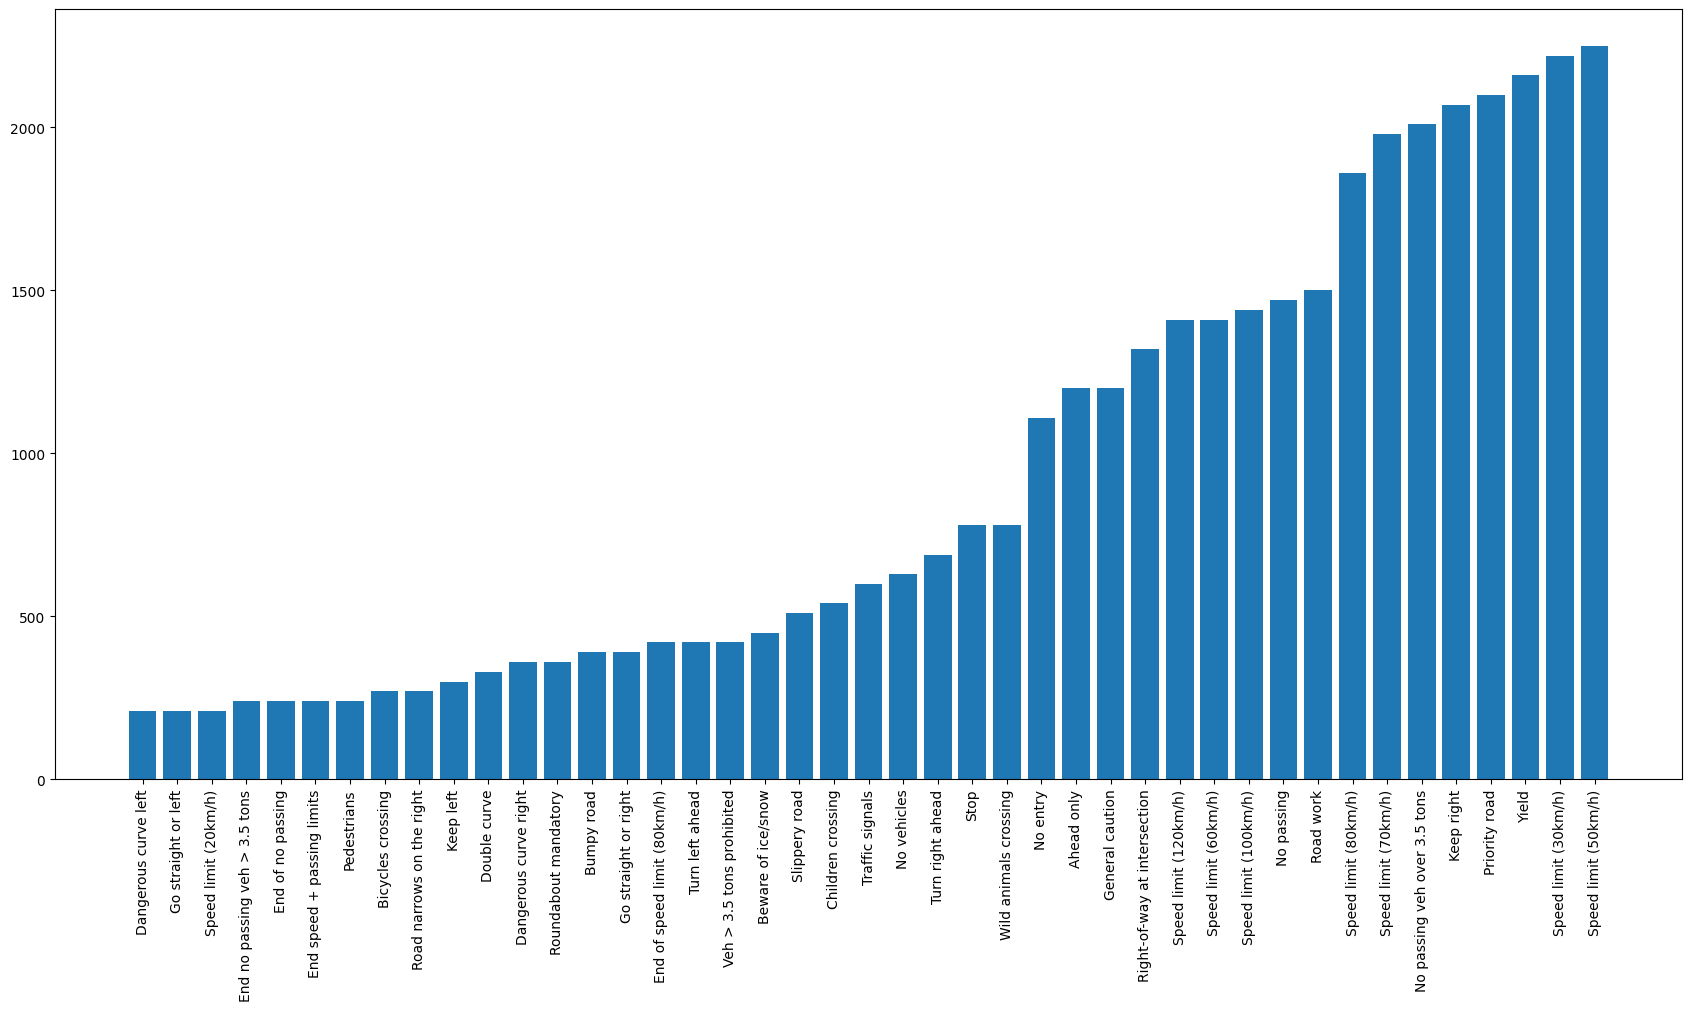

In [4]:
import os

classes = { 0:'Speed limit (20km/h)',
            1:'Speed limit (30km/h)', 
            2:'Speed limit (50km/h)', 
            3:'Speed limit (60km/h)', 
            4:'Speed limit (70km/h)', 
            5:'Speed limit (80km/h)', 
            6:'End of speed limit (80km/h)', 
            7:'Speed limit (100km/h)', 
            8:'Speed limit (120km/h)', 
            9:'No passing', 
            10:'No passing veh over 3.5 tons', 
            11:'Right-of-way at intersection', 
            12:'Priority road', 
            13:'Yield', 
            14:'Stop', 
            15:'No vehicles', 
            16:'Veh > 3.5 tons prohibited', 
            17:'No entry', 
            18:'General caution', 
            19:'Dangerous curve left', 
            20:'Dangerous curve right', 
            21:'Double curve', 
            22:'Bumpy road', 
            23:'Slippery road', 
            24:'Road narrows on the right', 
            25:'Road work', 
            26:'Traffic signals', 
            27:'Pedestrians', 
            28:'Children crossing', 
            29:'Bicycles crossing', 
            30:'Beware of ice/snow',
            31:'Wild animals crossing',
            32:'End speed + passing limits', 
            33:'Turn right ahead', 
            34:'Turn left ahead', 
            35:'Ahead only', 
            36:'Go straight or right', 
            37:'Go straight or left', 
            38:'Keep right', 
            39:'Keep left', 
            40:'Roundabout mandatory', 
            41:'End of no passing', 
            42:'End no passing veh > 3.5 tons' }
           
folders = os.listdir(train_path)

train_number = []
class_num = []

for folder in folders:
    train_files = os.listdir(train_path + '/' + folder)
    train_number.append(len(train_files))
    class_num.append(classes[int(folder)])
    
# Sorting the dataset on the basis of number of images in each class
zipped_lists = zip(train_number, class_num)
sorted_pairs = sorted(zipped_lists)
tuples = zip(*sorted_pairs)
train_number, class_num = [ list(tuple) for tuple in  tuples]

# Plotting the number of images in each class
plt.figure(figsize=(21,10))  
plt.bar(class_num, train_number)
plt.xticks(class_num, rotation='vertical')
plt.show()

In [ ]:
# Sign Detection + Crop
import cv2
import numpy as np

def detect_and_crop_sign(image):
    img = cv2.cvtColor(image, cv2.COLOR_RGB2BGR)
    hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)

    # Red mask (2 ranges)
    lower_red1 = np.array([0, 70, 50])
    upper_red1 = np.array([10, 255, 255])
    lower_red2 = np.array([170, 70, 50])
    upper_red2 = np.array([180, 255, 255])

    mask1 = cv2.inRange(hsv, lower_red1, upper_red1)
    mask2 = cv2.inRange(hsv, lower_red2, upper_red2)
    mask = mask1 + mask2

    contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    if len(contours) == 0:
        return image, None

    # pick largest contour
    cnt = max(contours, key=cv2.contourArea)

    x, y, w, h = cv2.boundingRect(cnt)

    # filter small noise
    if w*h < 500:
        return image, None

    crop = image[y:y+h, x:x+w]
    crop = cv2.resize(crop, (64, 64))

    return crop, (x, y, w, h)

Found 31368 images belonging to 43 classes.
Found 7841 images belonging to 43 classes.


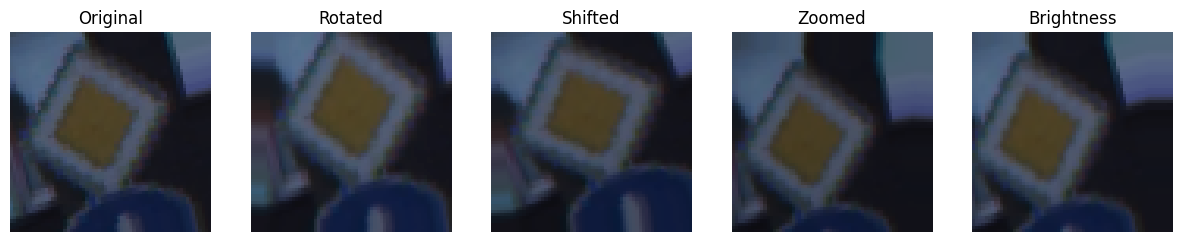

In [ ]:
# Data Augmentation
train_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,

    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1,
    brightness_range=[0.9, 1.1]
)
val_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)
train_gen = train_datagen.flow_from_directory(
    train_path,
    target_size=(64,64),
    batch_size=32,
    class_mode='categorical',
    subset='training',
    seed=42
)

val_gen = val_datagen.flow_from_directory(
    train_path,
    target_size=(64,64),
    batch_size=32,
    class_mode='categorical',
    subset='validation',
    seed=42
)
import matplotlib.pyplot as plt
import numpy as np

images, _ = next(train_gen)

img = (images[0] * 255).astype("uint8")

datagen = ImageDataGenerator(
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1,
    brightness_range=[0.9, 1.1]
)

aug_iter = datagen.flow(np.expand_dims(img, 0), batch_size=1)

aug_images = []
for _ in range(4):
    aug = next(aug_iter)[0]
    aug = np.clip(aug, 0, 255).astype("uint8")
    aug_images.append(aug)

# Plot
plt.figure(figsize=(15,3))
titles = ["Original", "Rotated", "Shifted", "Zoomed", "Brightness"]
all_images = [img] + aug_images

for i in range(5):
    plt.subplot(1,5,i+1)
    plt.imshow(all_images[i])
    plt.title(titles[i])
    plt.axis('off')

plt.show()

In [6]:
# Detect & Crop
import cv2
import numpy as np
def detect_and_crop_sign(image):
    # Convert to HSV
    hsv = cv2.cvtColor(image, cv2.COLOR_BGR2HSV)

    # 🔴 Red color range (two ranges in HSV)
    lower_red1 = np.array([0, 70, 50])
    upper_red1 = np.array([10, 255, 255])

    lower_red2 = np.array([170, 70, 50])
    upper_red2 = np.array([180, 255, 255])

    # Create masks
    mask1 = cv2.inRange(hsv, lower_red1, upper_red1)
    mask2 = cv2.inRange(hsv, lower_red2, upper_red2)

    mask = mask1 + mask2

    # Remove noise
    kernel = np.ones((5,5), np.uint8)
    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel)

    # Find contours
    contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    best_contour = None
    max_area = 0

    for cnt in contours:
        area = cv2.contourArea(cnt)

        if area > 500:  # filter small noise
            x, y, w, h = cv2.boundingRect(cnt)

            aspect_ratio = w / float(h)

            # Keep square-like shapes
            if 0.7 < aspect_ratio < 1.3:
                if area > max_area:
                    best_contour = cnt
                    max_area = area

    if best_contour is not None:
        x, y, w, h = cv2.boundingRect(best_contour)

        cropped = image[y:y+h, x:x+w]

        # Resize to model input
        cropped = cv2.resize(cropped, (64,64))

        return cropped, (x, y, w, h)

    else:
        # If nothing detected → return center crop
        h, w, _ = image.shape
        cropped = image[h//4:3*h//4, w//4:3*w//4]
        cropped = cv2.resize(cropped, (64,64))

        return cropped, None

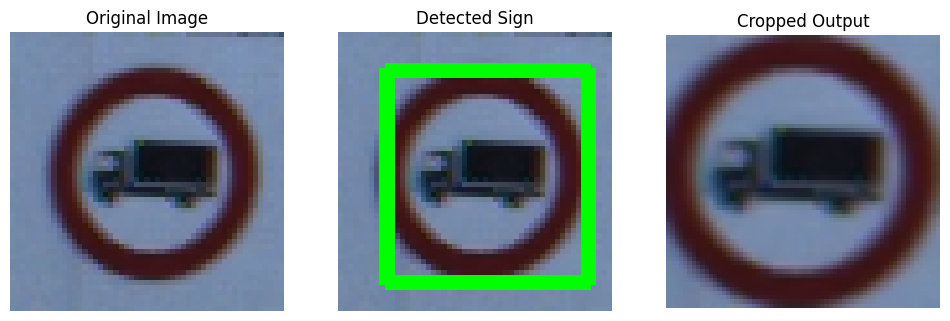

In [ ]:
# Test On 1 image
import matplotlib.pyplot as plt

# Read image
img = cv2.imread(r" img")
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

cropped, bbox = detect_and_crop_sign(img)

# Draw bounding box
img_box = img.copy()

if bbox:
    x, y, w, h = bbox
    cv2.rectangle(img_box, (x,y), (x+w, y+h), (0,255,0), 2)

img_box = cv2.cvtColor(img_box, cv2.COLOR_BGR2RGB)

# Plot
plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.imshow(img_rgb)
plt.title("Original Image")
plt.axis('off')

plt.subplot(1,3,2)
plt.imshow(img_box)
plt.title("Detected Sign")
plt.axis('off')

plt.subplot(1,3,3)
plt.imshow(cv2.cvtColor(cropped, cv2.COLOR_BGR2RGB))
plt.title("Cropped Output")
plt.axis('off')

plt.show()

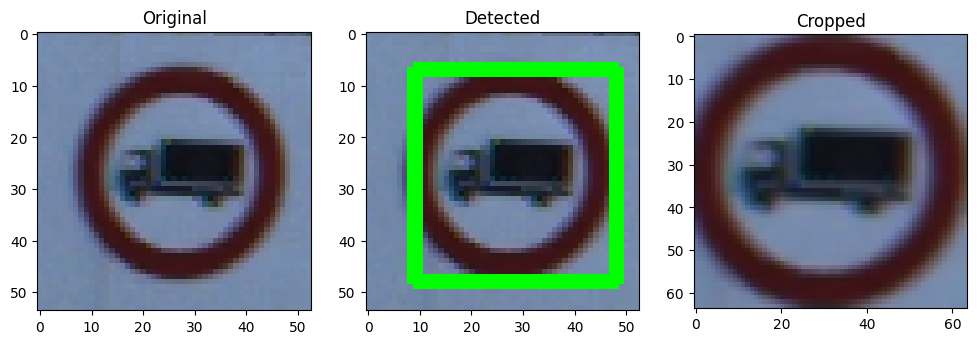

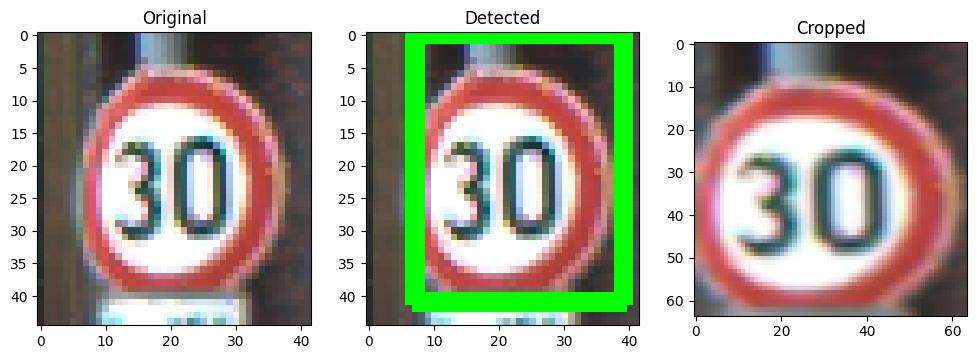

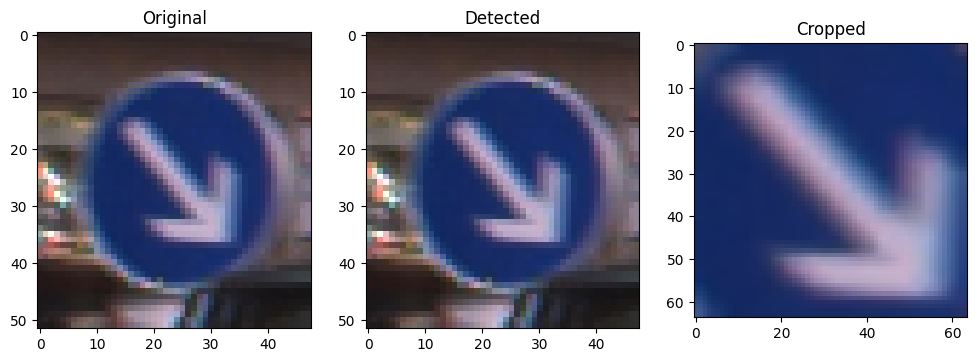

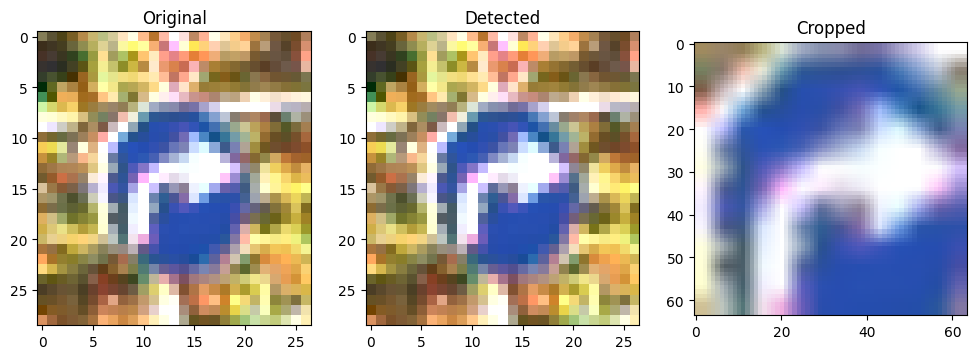

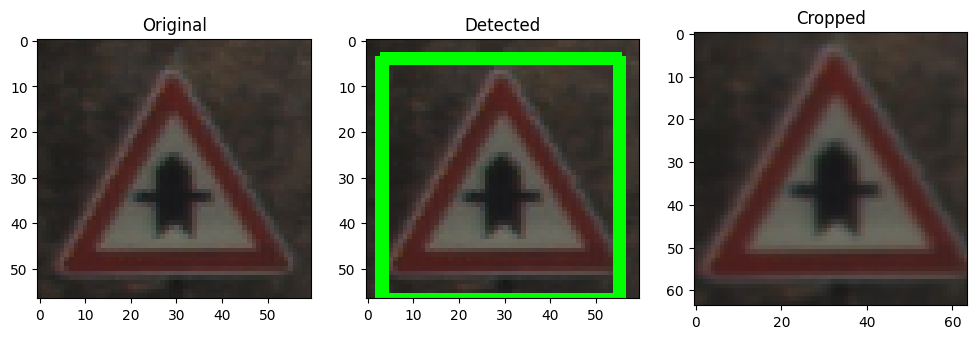

In [ ]:
# Test on multiple images
test_images = [r"img"]

for path in test_images:
    img = cv2.imread(path)

    cropped, bbox = detect_and_crop_sign(img)

    img_box = img.copy()
    if bbox:
        x,y,w,h = bbox
        cv2.rectangle(img_box, (x,y), (x+w,y+h), (0,255,0), 2)

    # Convert to RGB
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img_box = cv2.cvtColor(img_box, cv2.COLOR_BGR2RGB)
    crop_rgb = cv2.cvtColor(cropped, cv2.COLOR_BGR2RGB)

    plt.figure(figsize=(12,4))

    plt.subplot(1,3,1)
    plt.imshow(img_rgb)
    plt.title("Original")

    plt.subplot(1,3,2)
    plt.imshow(img_box)
    plt.title("Detected")

    plt.subplot(1,3,3)
    plt.imshow(crop_rgb)
    plt.title("Cropped")

    plt.show()

In [ ]:
'''
CNN Model Building
'''

'CNN Model Building'

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

def build_cnn(num_hidden_layers, neurons, input_shape=(64,64,3), num_classes=43):
    
    model = Sequential()

    # Shared backbone across all configs
    model.add(Conv2D(32, (3,3), activation='relu', input_shape=input_shape))
    model.add(MaxPooling2D(2,2))

    model.add(Conv2D(64, (3,3), activation='relu'))
    model.add(MaxPooling2D(2,2))

    model.add(Flatten())

    # 🔹 Custom Hidden Layers (VARIABLE)
    for _ in range(num_hidden_layers):
        model.add(Dense(neurons, activation='relu'))
        model.add(Dropout(0.3))

    # 🔹 Output Layer
    model.add(Dense(num_classes, activation='softmax'))

    # 🔹 Compile
    model.compile(
        optimizer='adam',
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    return model

In [15]:
configs = [
    {"num_hidden_layers": 1, "neurons": 128},
    {"num_hidden_layers": 2, "neurons": 256},
    {"num_hidden_layers": 3, "neurons": 512}
]

In [16]:
import pandas as pd
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

results = []

for i, config in enumerate(configs):

    print(f"\n🔹 Training Config {i+1}: {config}")

    model = build_cnn(
        num_hidden_layers=config["num_hidden_layers"],
        neurons=config["neurons"]
    )

    model.summary()  # 👈 REQUIRED in your question

    callbacks = [
        EarlyStopping(
            monitor='val_loss',
            patience=3,
            restore_best_weights=True
        ),

        ModelCheckpoint(
            f"cnn_config_{i+1}.keras",   # ✅ Keras 3 format
            monitor='val_accuracy',
            save_best_only=True
        )
    ]

    history = model.fit(
        train_gen,
        validation_data=val_gen,
        epochs=30,
        callbacks=callbacks,
        verbose=1
    )

    # 🔹 Store best results
    best_val_acc = max(history.history['val_accuracy'])
    best_val_loss = min(history.history['val_loss'])

    results.append({
        "Config": f"Config_{i+1}",
        "Hidden Layers": config["num_hidden_layers"],
        "Neurons": config["neurons"],
        "Best Val Accuracy": best_val_acc,
        "Best Val Loss": best_val_loss
    })


🔹 Training Config 1: {'num_hidden_layers': 1, 'neurons': 128}


c:\Users\agnes\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 62, 62, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 31, 31, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 29, 29, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 12544)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     1,605,760 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 43)             │         5,547 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,630,699 (6.22 MB)

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)               │ (None, 62, 62, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 31, 31, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 29, 29, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 12544)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 512)            │     6,423,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 512)            │       262,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 512)            │       262,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 43)             │        22,059 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,989,803 (26.66 MB)

 Trainable params: 6,989,803 (26.66 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30
981/981 ━━━━━━━━━━━━━━━━━━━━ 127s 127ms/step - accuracy: 0.3855 - loss: 1.9753 - val_accuracy: 0.5464 - val_loss: 1.3773
Epoch 2/30
981/981 ━━━━━━━━━━━━━━━━━━━━ 142s 145ms/step - accuracy: 0.6439 - loss: 1.0533 - val_accuracy: 0.7142 - val_loss: 0.8444
Epoch 3/30
981/981 ━━━━━━━━━━━━━━━━━━━━ 137s 140ms/step - accuracy: 0.7807 - loss: 0.6620 - val_accuracy: 0.7855 - val_loss: 0.6599
Epoch 4/30
981/981 ━━━━━━━━━━━━━━━━━━━━ 132s 135ms/step - accuracy: 0.8417 - loss: 0.4762 - val_accuracy: 0.8421 - val_loss: 0.5461
Epoch 5/30
981/981 ━━━━━━━━━━━━━━━━━━━━ 142s 145ms/step - accuracy: 0.8737 - loss: 0.3853 - val_accuracy: 0.8504 - val_loss: 0.4836
Epoch 6/30
981/981 ━━━━━━━━━━━━━━━━━━━━ 423s 431ms/step - accuracy: 0.8905 - loss: 0.3282 - val_accuracy: 0.8669 - val_loss: 0.4454
Epoch 7/30
981/981 ━━━━━━━━━━━━━━━━━━━━ 149s 152ms/step - accuracy: 0.9054 - loss: 0.2920 - val_accuracy: 0.8537 - val_loss: 0.5204
Epoch 8/30
981/981 ━━━━━━━━━━━━━━━━━━━━ 120s 122ms/step - accuracy: 0.9135 -

In [17]:
df_results = pd.DataFrame(results)
print(df_results)

     Config  Hidden Layers  Neurons  Best Val Accuracy  Best Val Loss
0  Config_1              1      128           0.871700       0.446966
1  Config_2              2      256           0.907410       0.370857
2  Config_3              3      512           0.896697       0.409106


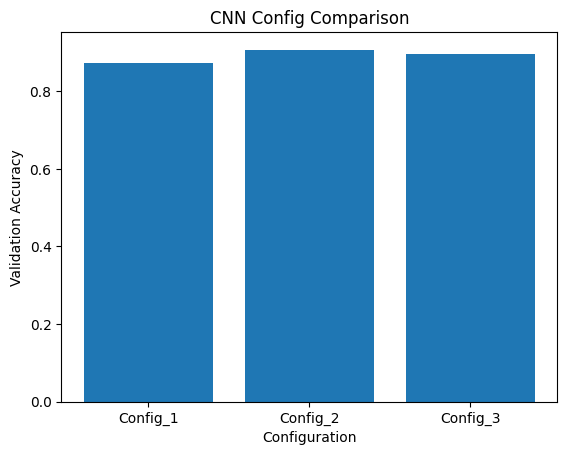

In [18]:
import matplotlib.pyplot as plt

plt.figure()
plt.bar(df_results["Config"], df_results["Best Val Accuracy"])
plt.xlabel("Configuration")
plt.ylabel("Validation Accuracy")
plt.title("CNN Config Comparison")
plt.show()

In [19]:
best_config = df_results.loc[df_results["Best Val Accuracy"].idxmax()]
print("\nBest Configuration:\n", best_config)


Best Configuration:
 Config               Config_2
Hidden Layers               2
Neurons                   256
Best Val Accuracy     0.90741
Best Val Loss        0.370857
Name: 1, dtype: object


In [22]:
ModelCheckpoint("cnn_config_X.h5")

In [ ]:
'''
MobileNetv2
'''


In [23]:
IMG_SIZE = 64
BATCH_SIZE = 32
NUM_CLASSES = 43

In [ ]:
import time
import os
import tensorflow as tf
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Model
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam
base_model = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(IMG_SIZE, IMG_SIZE, 3)
)


for layer in base_model.layers[-50:]:
    layer.trainable = True

# Add custom head
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.3)(x)
outputs = Dense(NUM_CLASSES, activation='softmax')(x)

mobilenet_model = Model(inputs=base_model.input, outputs=outputs)


mobilenet_model.compile(
    
    optimizer=Adam(learning_rate=0.0001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)
start_time = time.time()

history_mobilenet = mobilenet_model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=15,
    callbacks=[
        EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)
    ]
)

end_time = time.time()

mobilenet_train_time = (end_time - start_time) / 60  # minutes




C:\Users\agnes\AppData\Local\Temp\ipykernel_16400\3383202342.py:9: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = MobileNetV2(


Epoch 1/15
981/981 ━━━━━━━━━━━━━━━━━━━━ 357s 337ms/step - accuracy: 0.4931 - loss: 1.8703 - val_accuracy: 0.5442 - val_loss: 1.9445
Epoch 2/15
981/981 ━━━━━━━━━━━━━━━━━━━━ 529s 540ms/step - accuracy: 0.8328 - loss: 0.5482 - val_accuracy: 0.7539 - val_loss: 1.1120
Epoch 3/15
981/981 ━━━━━━━━━━━━━━━━━━━━ 426s 433ms/step - accuracy: 0.9203 - loss: 0.2549 - val_accuracy: 0.8593 - val_loss: 0.5868
Epoch 4/15
981/981 ━━━━━━━━━━━━━━━━━━━━ 295s 300ms/step - accuracy: 0.9502 - loss: 0.1629 - val_accuracy: 0.8759 - val_loss: 0.5055
Epoch 5/15
981/981 ━━━━━━━━━━━━━━━━━━━━ 286s 292ms/step - accuracy: 0.9643 - loss: 0.1190 - val_accuracy: 0.8581 - val_loss: 0.6594
Epoch 6/15
981/981 ━━━━━━━━━━━━━━━━━━━━ 307s 313ms/step - accuracy: 0.9719 - loss: 0.0929 - val_accuracy: 0.9021 - val_loss: 0.4433
Epoch 7/15
981/981 ━━━━━━━━━━━━━━━━━━━━ 371s 378ms/step - accuracy: 0.9775 - loss: 0.0744 - val_accuracy: 0.9189 - val_loss: 0.3682
Epoch 8/15
981/981 ━━━━━━━━━━━━━━━━━━━━ 342s 348ms/step - accuracy: 0.9798 -

In [28]:
mobilenet_model.save("mobilenet_model.h5")

In [29]:
# Model Size
mobilenet_size = os.path.getsize("mobilenet_model.keras") / (1024 * 1024)  # MB

In [53]:
df_test['Path'] = df_test['Path'].apply(
    lambda x: test_path + "\\" + x.split("/")[-1]
)

In [54]:
df_test['ClassId'] = df_test['ClassId'].astype(str)

In [ ]:
import os

for i in range(5):
    print(df_test['Path'].iloc[i], os.path.exists(df_test['Path'].iloc[i]))

In [56]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

test_datagen = ImageDataGenerator(rescale=1./255)

test_gen = test_datagen.flow_from_dataframe(
    dataframe=df_test,
    x_col='Path',
    y_col='ClassId',
    target_size=(64, 64),
    batch_size=32,
    class_mode='categorical',
    shuffle=False
)

Found 12630 validated image filenames belonging to 43 classes.


In [57]:
print("Total test images:", test_gen.samples)
print("Classes:", test_gen.class_indices)

Total test images: 12630
Classes: {'0': 0, '1': 1, '10': 2, '11': 3, '12': 4, '13': 5, '14': 6, '15': 7, '16': 8, '17': 9, '18': 10, '19': 11, '2': 12, '20': 13, '21': 14, '22': 15, '23': 16, '24': 17, '25': 18, '26': 19, '27': 20, '28': 21, '29': 22, '3': 23, '30': 24, '31': 25, '32': 26, '33': 27, '34': 28, '35': 29, '36': 30, '37': 31, '38': 32, '39': 33, '4': 34, '40': 35, '41': 36, '42': 37, '5': 38, '6': 39, '7': 40, '8': 41, '9': 42}


In [51]:
import os
print(os.listdir(test_path)[:10])

['00000.png', '00001.png', '00002.png', '00003.png', '00004.png', '00005.png', '00006.png', '00007.png', '00008.png', '00009.png']


In [58]:
# Inference Time
import numpy as np
sample_batch = next(test_gen)[0][:100]  # 100 images

start = time.time()
mobilenet_model.predict(sample_batch)
end = time.time()

mobilenet_inference_time = ((end - start) / 100) * 1000  # ms per image

1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step


In [32]:
mobilenet_val_acc = max(history_mobilenet.history['val_accuracy'])
print("Accuracy :", mobilenet_val_acc)

Accuracy : 0.9483484029769897


In [ ]:
'''
Resnet50
'''


In [33]:
IMG_SIZE = 64
BATCH_SIZE = 32
NUM_CLASSES = 43

In [35]:
from tensorflow.keras.applications import ResNet50
base_model_resnet = ResNet50(
    weights='imagenet',
    include_top=False,
    input_shape=(IMG_SIZE, IMG_SIZE, 3)
)

# Freeze base
for layer in base_model_resnet.layers[-50:]:
    layer.trainable = True

# Custom head
x = base_model_resnet.output
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.3)(x)
outputs = Dense(NUM_CLASSES, activation='softmax')(x)

resnet_model = Model(inputs=base_model_resnet.input, outputs=outputs)
resnet_model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

start_time = time.time()

history_resnet = resnet_model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=15,
    callbacks=[
        EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)
    ]
)

end_time = time.time()

resnet_train_time = (end_time - start_time) / 60

Epoch 1/15
981/981 ━━━━━━━━━━━━━━━━━━━━ 1806s 2s/step - accuracy: 0.7971 - loss: 0.7556 - val_accuracy: 0.8947 - val_loss: 0.3535
Epoch 2/15
981/981 ━━━━━━━━━━━━━━━━━━━━ 1605s 2s/step - accuracy: 0.9736 - loss: 0.0942 - val_accuracy: 0.9563 - val_loss: 0.1595
Epoch 3/15
981/981 ━━━━━━━━━━━━━━━━━━━━ 1003s 1s/step - accuracy: 0.9848 - loss: 0.0587 - val_accuracy: 0.9550 - val_loss: 0.1828
Epoch 4/15
981/981 ━━━━━━━━━━━━━━━━━━━━ 973s 992ms/step - accuracy: 0.9896 - loss: 0.0383 - val_accuracy: 0.9674 - val_loss: 0.1282
Epoch 5/15
981/981 ━━━━━━━━━━━━━━━━━━━━ 1001s 1s/step - accuracy: 0.9898 - loss: 0.0380 - val_accuracy: 0.9735 - val_loss: 0.1111
Epoch 6/15
981/981 ━━━━━━━━━━━━━━━━━━━━ 1454s 1s/step - accuracy: 0.9924 - loss: 0.0319 - val_accuracy: 0.9523 - val_loss: 0.2293
Epoch 7/15
981/981 ━━━━━━━━━━━━━━━━━━━━ 1736s 2s/step - accuracy: 0.9938 - loss: 0.0258 - val_accuracy: 0.9749 - val_loss: 0.1468
Epoch 8/15
981/981 ━━━━━━━━━━━━━━━━━━━━ 2035s 2s/step - accuracy: 0.9952 - loss: 0.0197 

In [37]:
resnet_model.save("resnet_model.h5")

In [38]:
# Model Size
resnet_size = os.path.getsize("resnet_model.keras") / (1024 * 1024)

In [59]:
# Inference Time
sample_batch = next(test_gen)[0][:100]

start = time.time()
resnet_model.predict(sample_batch)
end = time.time()

resnet_inference_time = ((end - start) / 100) * 1000

1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step


In [60]:
# Accuracy
resnet_val_acc = max(history_resnet.history['val_accuracy'])

In [61]:
# Final Comparison
import pandas as pd

results = pd.DataFrame({
    "Model": ["MobileNetV2", "ResNet50"],
    "Val Accuracy": [mobilenet_val_acc, resnet_val_acc],
    "Training Time (min)": [mobilenet_train_time, resnet_train_time],
    "Model Size (MB)": [mobilenet_size, resnet_size],
    "Inference Time (ms)": [mobilenet_inference_time, resnet_inference_time]
})

print(results)

         Model  Val Accuracy  Training Time (min)  Model Size (MB)  \
0  MobileNetV2      0.948348            71.384340        28.189621   
1     ResNet50      0.974876           193.592043       273.376272   

   Inference Time (ms)  
0            56.564898  
1            32.267983  


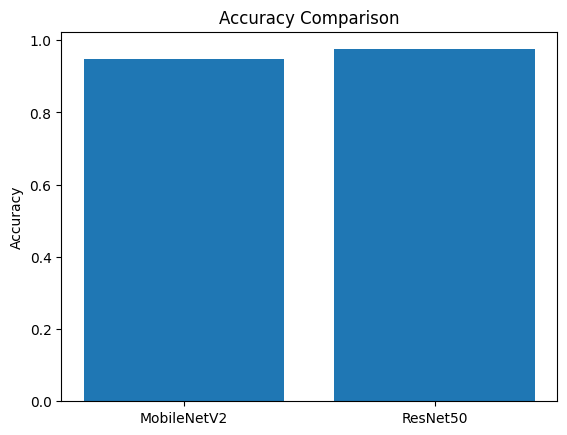

In [62]:
# Plot
import matplotlib.pyplot as plt

plt.figure()
plt.bar(results["Model"], results["Val Accuracy"])
plt.title("Accuracy Comparison")
plt.ylabel("Accuracy")
plt.show()

In [82]:
class_indices = test_gen.class_indices
class_labels = {v: k for k, v in class_indices.items()}
images, labels = next(test_gen)
images = images[:25]
labels = labels[:25]

In [79]:
import numpy as np

preds = resnet_model.predict(images)

pred_classes = np.argmax(preds, axis=1)
true_classes = np.argmax(labels, axis=1)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 442ms/step


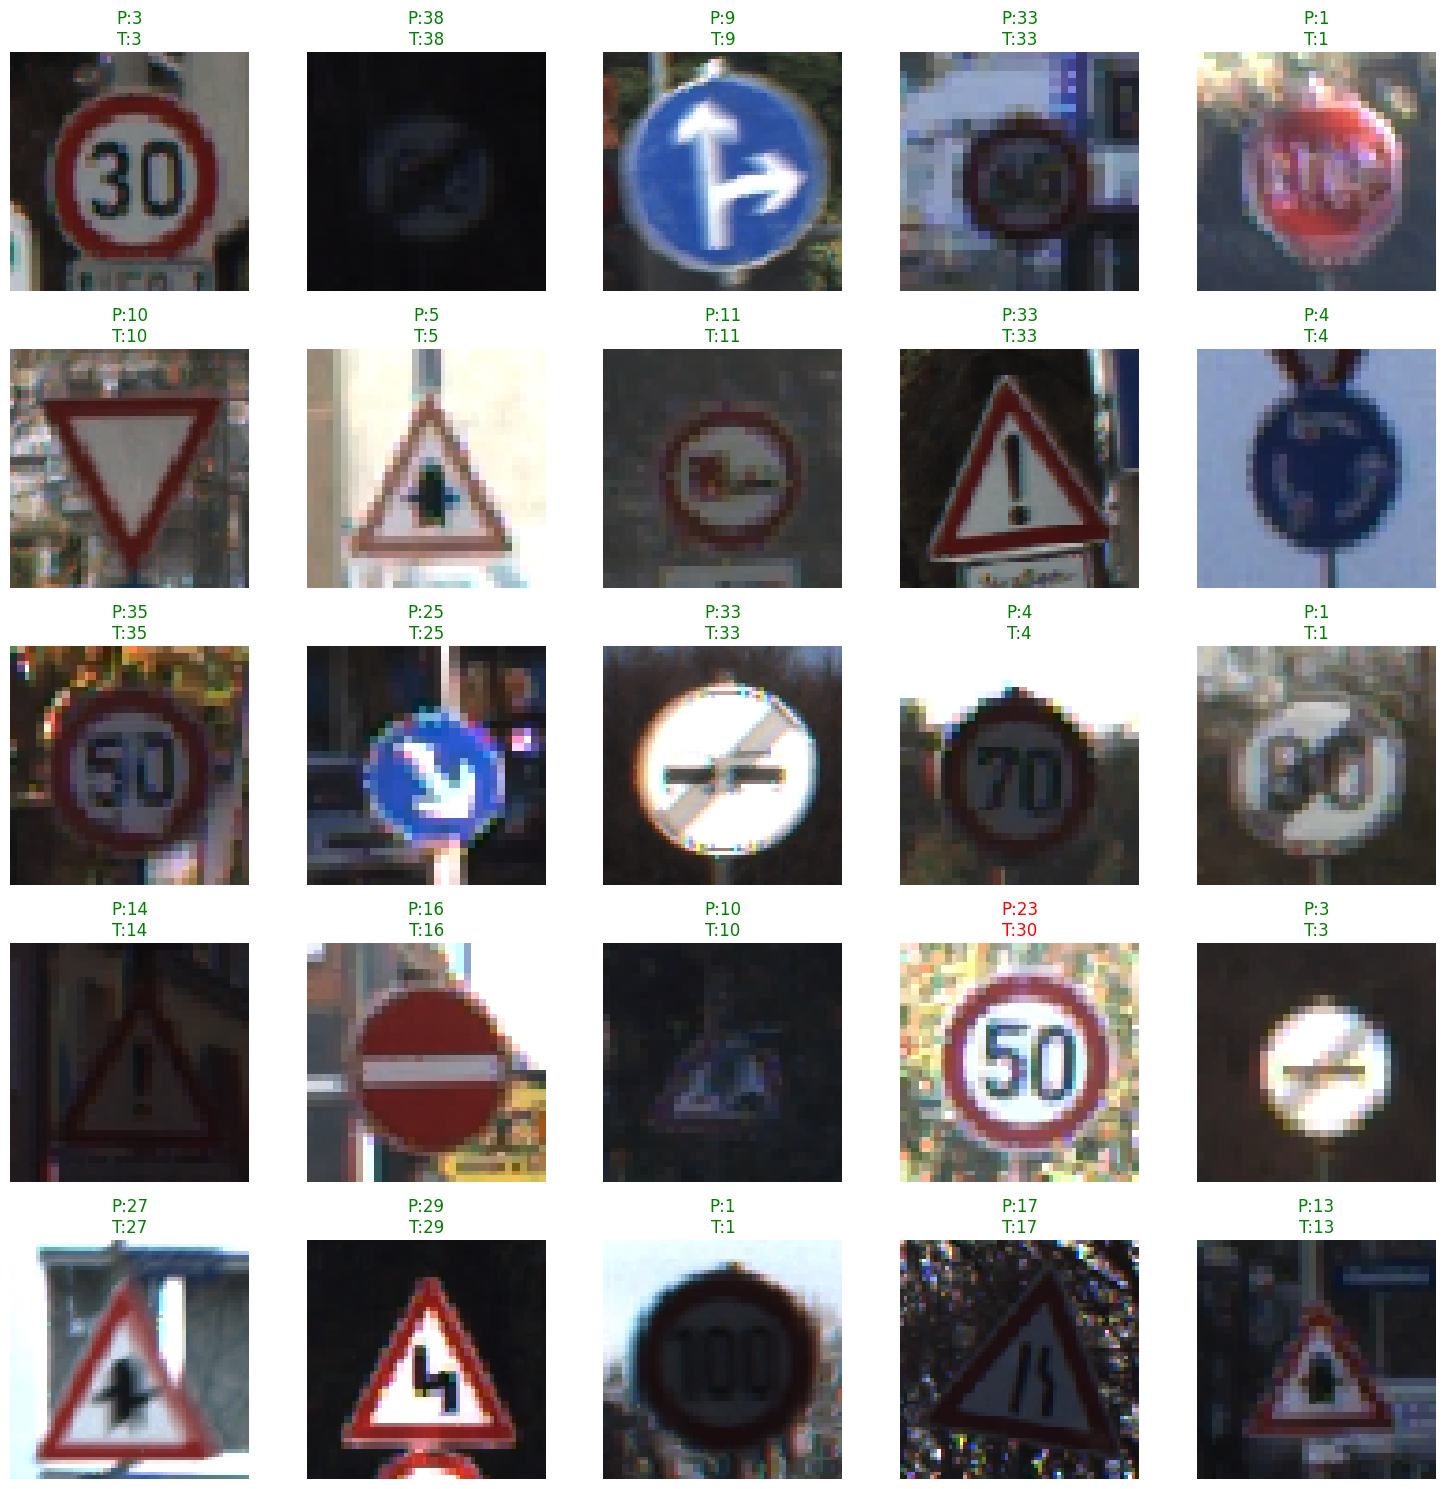

In [83]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 15))

for i in range(25):
    plt.subplot(5, 5, i+1)
    plt.imshow(images[i])
    
    pred = class_labels[pred_classes[i]]
    true = class_labels[true_classes[i]]
    
    color = 'green' if pred == true else 'red'
    
    plt.title(f"P:{pred}\nT:{true}", color=color)
    plt.axis('off')

plt.tight_layout()
plt.show()

In [84]:
accuracy = np.mean(pred_classes == true_classes)
print("Accuracy on 25 samples:", accuracy)

Accuracy on 25 samples: 0.96875


In [ ]:
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)               │ (None, 62, 62, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 31, 31, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 29, 29, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 12544)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 512)            │     6,423,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 512)            │       262,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 512)            │       262,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 43)             │        22,059 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 20,969,411 (79.99 MB)

 Trainable params: 6,989,803 (26.66 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 13,979,608 (53.33 MB)

In [ ]:
'''
Model Evaluation
'''

In [87]:
# Evaluate on test data
loss, accuracy = resnet_model.evaluate(test_gen)

print("Test Loss:", loss)
print("Test Accuracy:", accuracy)

395/395 ━━━━━━━━━━━━━━━━━━━━ 102s 259ms/step - accuracy: 0.9702 - loss: 0.1272
Test Loss: 0.12716227769851685
Test Accuracy: 0.9702296257019043


In [86]:
# Get Predictions on full test set
import numpy as np

pred_probs = resnet_model.predict(test_gen)

y_pred = np.argmax(pred_probs, axis=1)
y_true = test_gen.classes

395/395 ━━━━━━━━━━━━━━━━━━━━ 126s 309ms/step


In [88]:
# Classification Report
import numpy as np

pred_probs = resnet_model.predict(test_gen)

y_pred = np.argmax(pred_probs, axis=1)
y_true = test_gen.classes

395/395 ━━━━━━━━━━━━━━━━━━━━ 131s 332ms/step


In [ ]:

from sklearn.metrics import classification_report

class_labels = list(test_gen.class_indices.keys())

report = classification_report(
    y_true,
    y_pred,
    target_names=class_labels
)

print(report)

              precision    recall  f1-score   support

           0       0.91      1.00      0.95        60
           1       0.99      0.99      0.99       720
          10       1.00      1.00      1.00       660
          11       0.99      0.98      0.99       420
          12       0.99      0.99      0.99       690
          13       1.00      1.00      1.00       720
          14       0.95      1.00      0.97       270
          15       1.00      0.98      0.99       210
          16       1.00      1.00      1.00       150
          17       1.00      0.91      0.95       360
          18       1.00      0.85      0.92       390
          19       1.00      1.00      1.00        60
           2       0.98      0.99      0.99       750
          20       0.98      1.00      0.99        90
          21       0.88      0.96      0.91        90
          22       1.00      0.78      0.87       120
          23       0.86      1.00      0.93       150
          24       1.00    

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 396ms/step


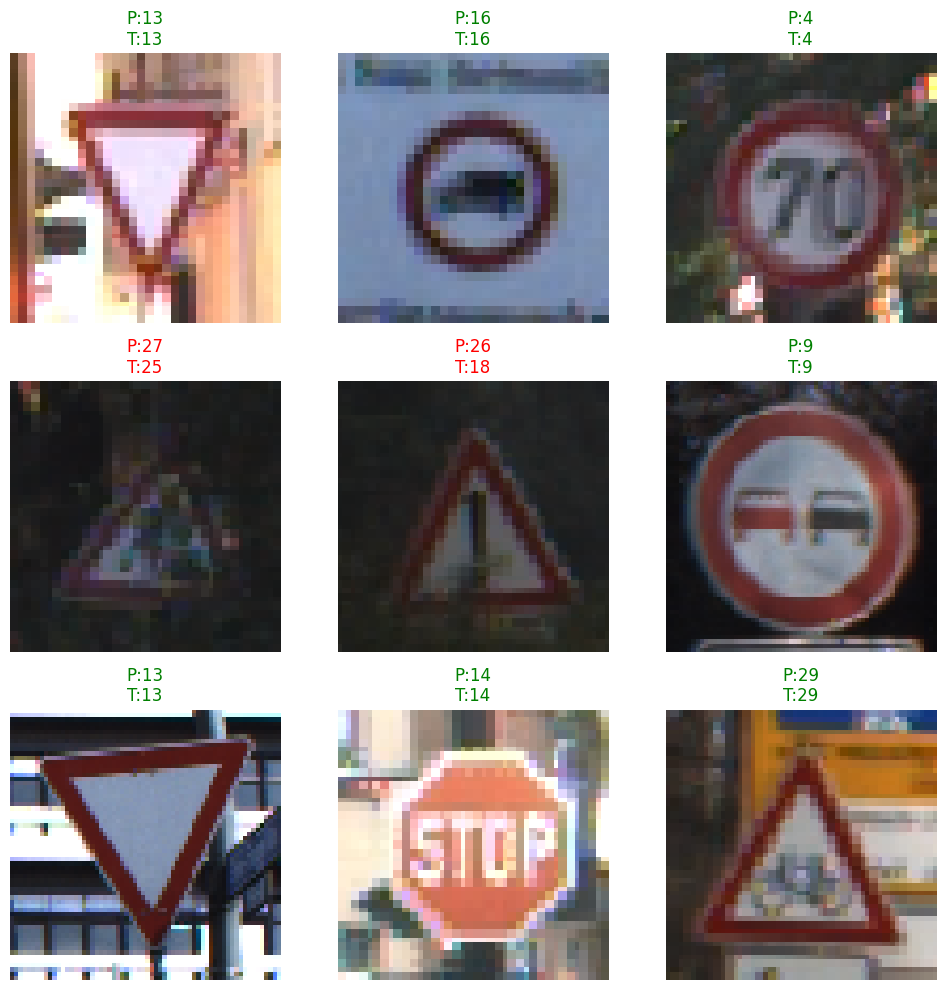

In [90]:
# Show 9 samples predictions
import matplotlib.pyplot as plt

images, labels = next(test_gen)

images = images[:9]
labels = labels[:9]

preds = resnet_model.predict(images)

pred_classes = np.argmax(preds, axis=1)
true_classes = np.argmax(labels, axis=1)

class_labels = {v:k for k,v in test_gen.class_indices.items()}

plt.figure(figsize=(10,10))

for i in range(9):
    plt.subplot(3,3,i+1)
    plt.imshow(images[i])
    
    pred = class_labels[pred_classes[i]]
    true = class_labels[true_classes[i]]
    
    color = "green" if pred == true else "red"
    
    plt.title(f"P:{pred}\nT:{true}", color=color)
    plt.axis('off')

plt.tight_layout()
plt.show()

In [91]:
print(model.input_shape)

(None, 64, 64, 3)


395/395 ━━━━━━━━━━━━━━━━━━━━ 107s 266ms/step


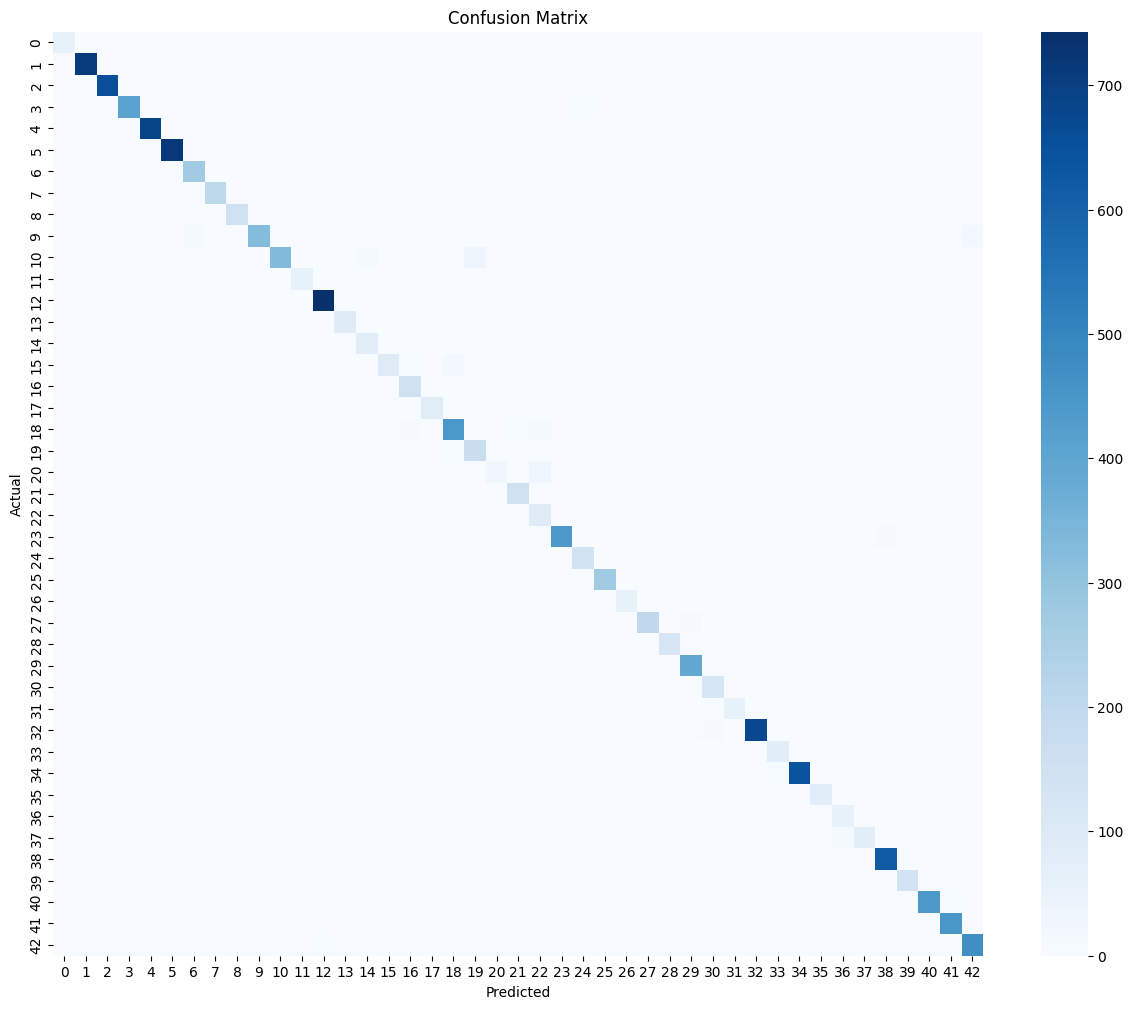

In [19]:
# Confusion Matrix

import numpy as np
from tensorflow.keras.models import load_model
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

resnet_model=load_model("resnet_model.h5")
pred_probs = resnet_model.predict(test_gen)

y_pred = np.argmax(pred_probs, axis=1)
y_true = test_gen.classes
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(15, 12))
sns.heatmap(cm, cmap='Blues')

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show() 